# 🏦 Bank Marketing Campaign: Deposit Prediction

Proyek *machine learning* untuk memprediksi potensi nasabah dalam membuka deposito. Model ini membantu menentukan prioritas target *telemarketing campaign* berdasarkan hasil klasifikasi dan probabilitas prediksi.

**Creator:** Aris Sando Hamzah

## Import Modul

In [181]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Manipulasi dan visualisasi data
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Split, cross-validation, dan hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

# Evaluation metrics
from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

# Feature engineering dan preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## Import Data

In [182]:
df=pd.read_csv('data_bank_marketing_campaign.csv')
df

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no


### Deskripsi Kolom

| Kolom | Deskripsi |
|---|---|
| `age` | Usia nasabah dalam tahun. |
| `job` | Jenis pekerjaan nasabah. |
| `balance` | Rata-rata saldo tahunan nasabah. |
| `housing` | Status kepemilikan pinjaman perumahan (`yes`/`no`). |
| `loan` | Status kepemilikan pinjaman pribadi (`yes`/`no`). |
| `contact` | Jenis media komunikasi yang digunakan untuk menghubungi nasabah. |
| `month` | Bulan terakhir nasabah dihubungi. |
| `campaign` | Jumlah kontak yang dilakukan kepada nasabah selama kampanye berjalan. |
| `pdays` | Jumlah hari sejak nasabah terakhir dihubungi pada kampanye sebelumnya; `-1` berarti belum pernah dihubungi. |
| `poutcome` | Hasil kampanye pemasaran sebelumnya. |
| `deposit` | Target yang menunjukkan apakah nasabah berlangganan deposito (`yes`/`no`). |

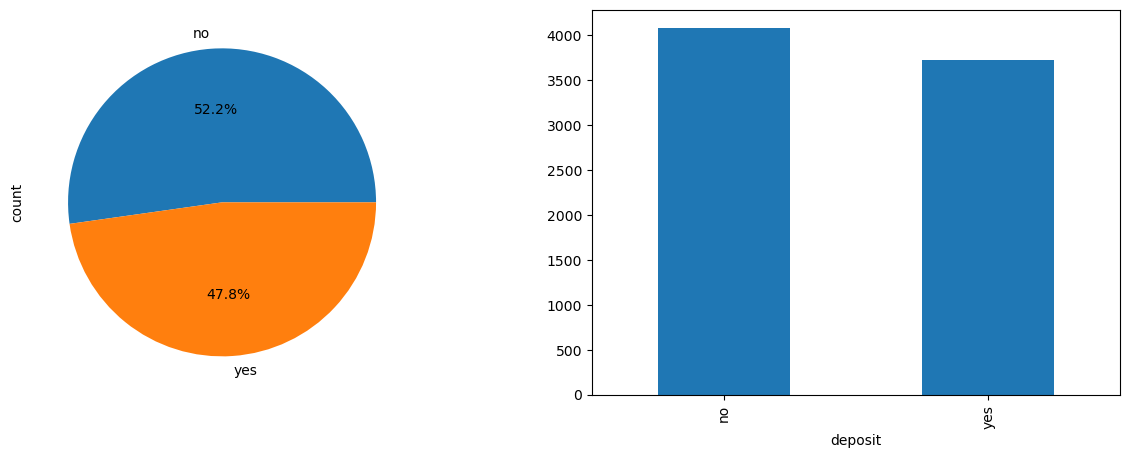

In [183]:
#cek target distribution pie & bar dengan subplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
df['deposit'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0])
df['deposit'].value_counts().plot(kind='bar', ax=ax[1])
plt.show()

## Simple Data Cleaning

In [184]:
#cek data duplikat
print('Duplikat sebelum:', df.duplicated().sum())

df = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

print('Duplikat setelah:', df.duplicated().sum())

Duplikat sebelum: 8
Duplikat setelah: 0


In [185]:
#handle irrelevant data
for i in df.columns:
    print(i)
    print(df[i].unique())
    print("="*100)

age
[55 39 51 38 36 41 37 35 57 23 33 31 53 30 46 48 25 29 28 52 49 44 42 27
 47 64 26 34 56 32 58 45 54 50 79 65 40 24 60 43 61 59 62 68 82 71 73 76
 69 20 72 22 67 19 70 75 63 93 77 80 66 21 87 81 92 88 84 83 78 74 18 85
 95 86 90]
job
['admin.' 'self-employed' 'services' 'housemaid' 'technician' 'management'
 'student' 'blue-collar' 'entrepreneur' 'retired' 'unemployed' 'unknown']
balance
[ 1662 -3058  3025 ...  4108 13901  5473]
housing
['no' 'yes']
loan
['no' 'yes']
contact
['cellular' 'telephone' 'unknown']
month
['jun' 'apr' 'may' 'nov' 'jan' 'sep' 'feb' 'mar' 'aug' 'jul' 'oct' 'dec']
campaign
[ 2  3  1  4  5  6  7 30  8  9 11 14 10 28 63 12 24 17 15 18 19 13 21 23
 22 33 16 25 26 20 29 43]
pdays
[ -1 352  21  91 186 263  96 355 294 412  89 114 276  93 175  57 323 156
  86  95 271 182 289 334 269 309 144 183 417 138 254 337 171 389  87 170
 165 372 247  98 196 469 272 104  63 587 336 145 130  28 202 324 147  94
 328 420 179  90  81 160 298 356 357 267 430  52 181 365 237 330 103

In [186]:
# Asumsi analitis: kategori 'other' dianggap sebagai outcome sebelumnya
# yang tidak spesifik, sehingga digabungkan dengan kategori 'unknown'.
df['poutcome'] = np.where(
    df['poutcome'] == 'other',
    'unknown',
    df['poutcome']
)


In [187]:
#cek missing value

df_missing=pd.DataFrame(100*df.isna().sum()/len(df)).rename(columns={0:'missing_percentage'})
df_missing['null_category']=np.where(df_missing['missing_percentage']>=10,'High',
                                 np.where(df_missing['missing_percentage']>=5,'Medium',
                                'Low'))
df_missing=df_missing.sort_values(by='missing_percentage',ascending=False).reset_index()
df_missing

,index,missing_percentage,null_category
0,age,0.0,Low
1,job,0.0,Low
2,balance,0.0,Low
3,housing,0.0,Low
4,loan,0.0,Low
5,contact,0.0,Low
6,month,0.0,Low
7,campaign,0.0,Low
8,pdays,0.0,Low
9,poutcome,0.0,Low


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7805 non-null   int64 
 1   job       7805 non-null   object
 2   balance   7805 non-null   int64 
 3   housing   7805 non-null   object
 4   loan      7805 non-null   object
 5   contact   7805 non-null   object
 6   month     7805 non-null   object
 7   campaign  7805 non-null   int64 
 8   pdays     7805 non-null   int64 
 9   poutcome  7805 non-null   object
 10  deposit   7805 non-null   object
dtypes: int64(4), object(7)
memory usage: 670.9+ KB


## EDA (Exploratory Data Analysis)

In [189]:
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,unknown,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


### Numerical vs Target

age
0.04641671956478091


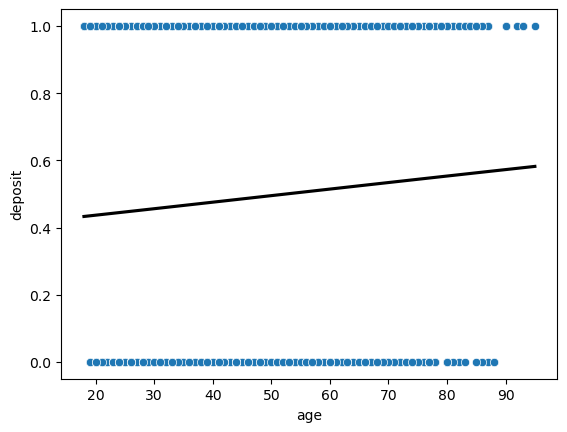

balance
0.09240252019935198


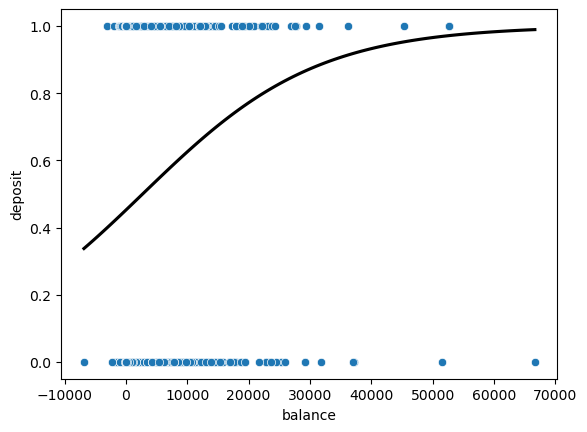

campaign
-0.13376634390389086


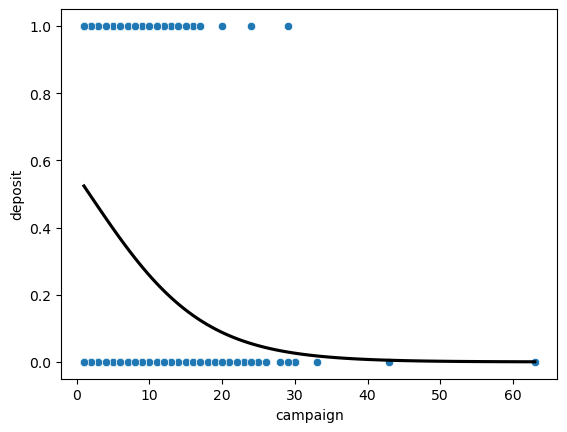

pdays
0.15781717869767298


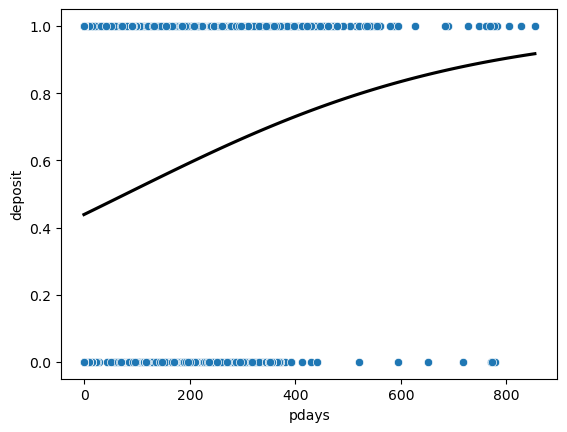

In [190]:
# Ubah target menjadi boolean
df["deposit"] = df["deposit"].map({
    "yes": True,
    "no": False
})

for i in df.select_dtypes(include=['int64','float64']):
    if i not in  ['deposit','index']:
      print(i)
      print(df[i].corr(df['deposit']))
      sns.scatterplot(x=i, y='deposit', data=df)
      sns.regplot(x=i, y='deposit', data=df, scatter=False, color='black', ci=None, logistic=True)
      plt.show()

age
0.04641671956478091


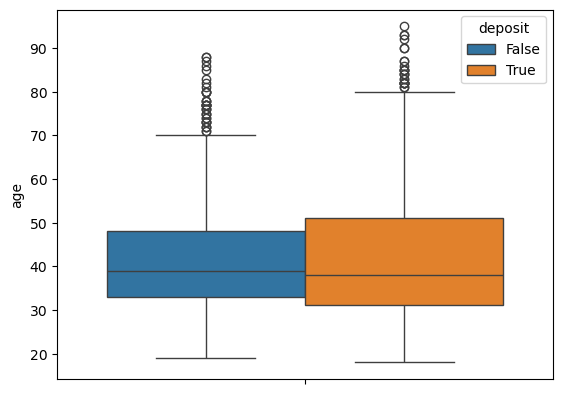

balance
0.09240252019935198


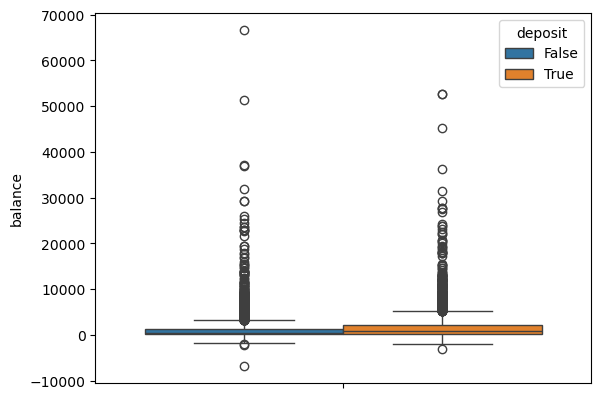

campaign
-0.13376634390389086


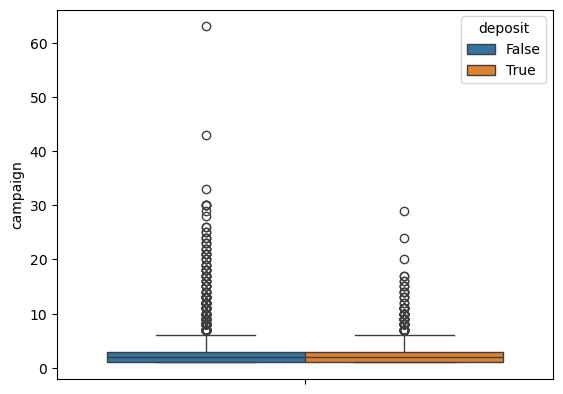

pdays
0.15781717869767298


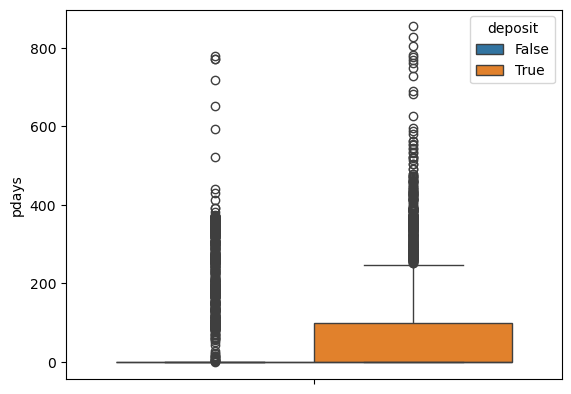

In [191]:
for i in df.select_dtypes(include=['int64','float64']):
    if i not in  ['deposit','index']:
      print(i)
      print(df[i].corr(df['deposit']))
      sns.boxplot(hue='deposit', y=i, data=df)
      plt.show()

### Categorical Features

job


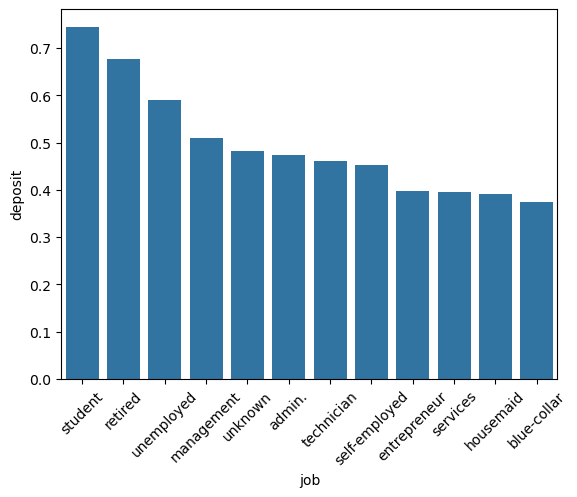

housing


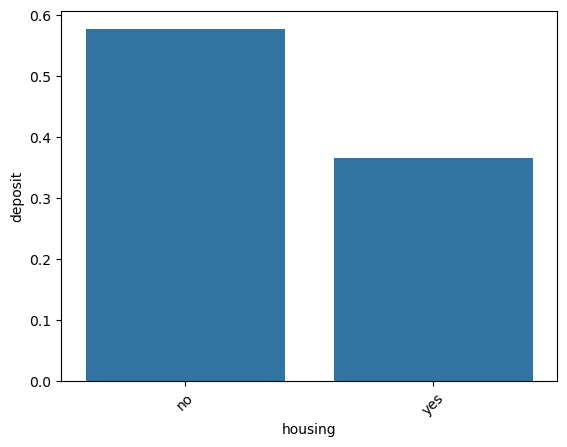

loan


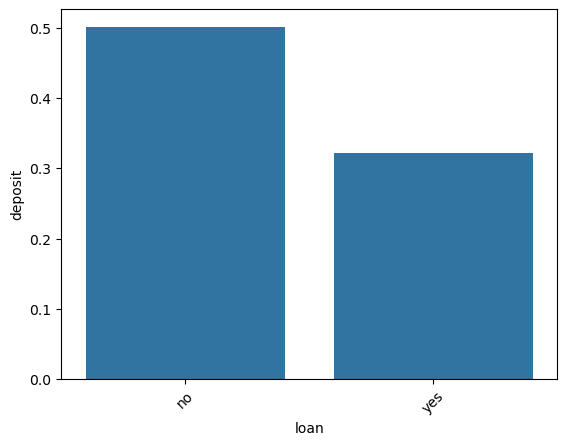

contact


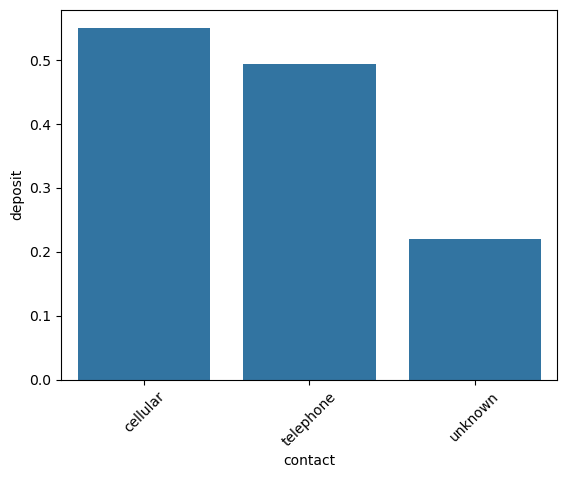

month


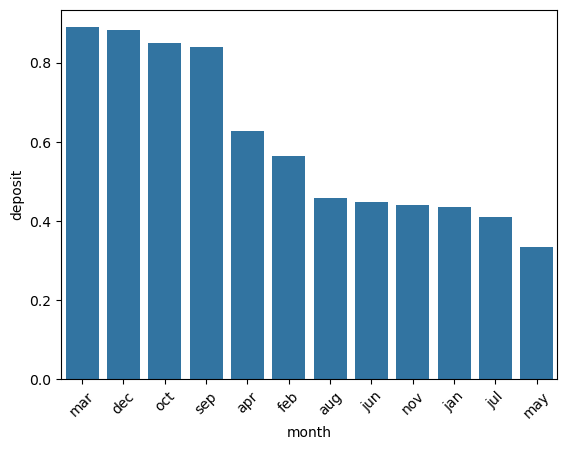

poutcome


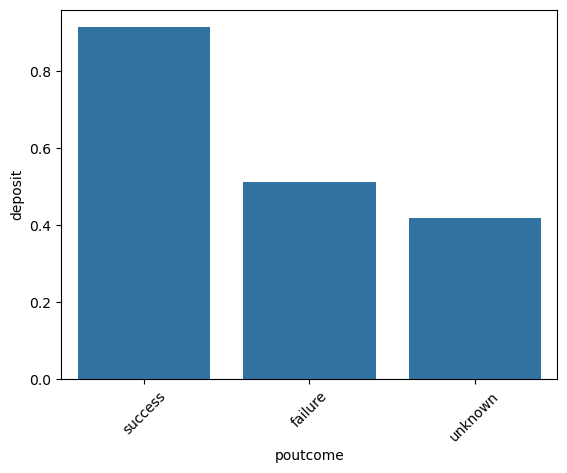

In [192]:
for i in df.select_dtypes(include='object'):
    print(i)
    df_agg=df.groupby(i)['deposit'].mean().reset_index().sort_values('deposit',ascending=False)
    sns.barplot(x=i, y='deposit', data=df_agg)
    plt.xticks(rotation=45)
    plt.show()

### Identify Outlier

#### Univariate Outlier

age


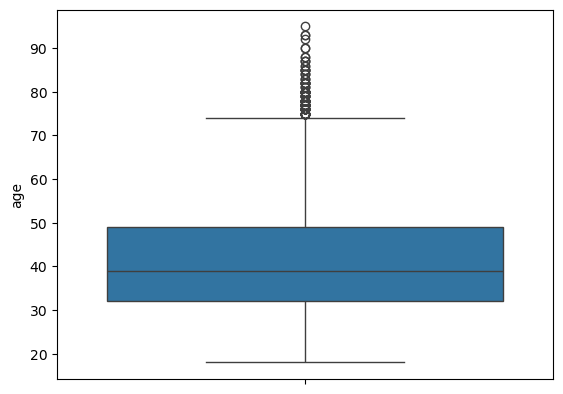



balance


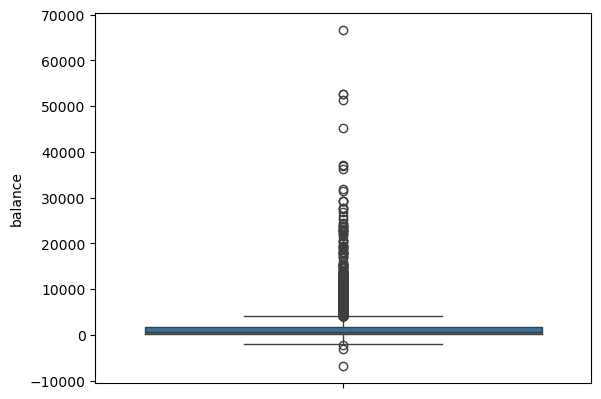



campaign


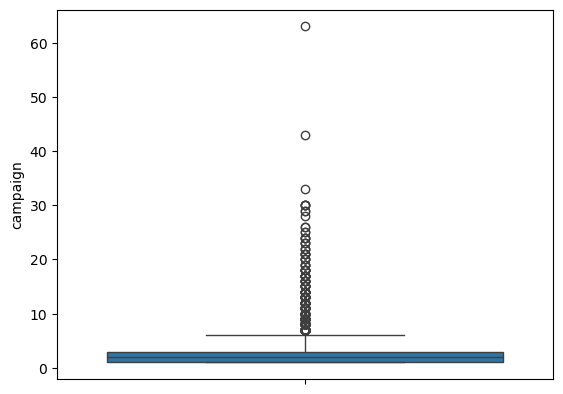



pdays


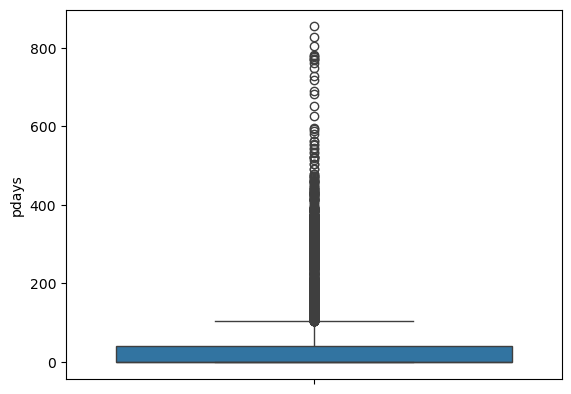

In [193]:
for i in df.select_dtypes('number').columns:
    if i not in ['index','deposit']:
        print(i)
        sns.boxplot(y=df[i])
        plt.show()
        print('\n')

age


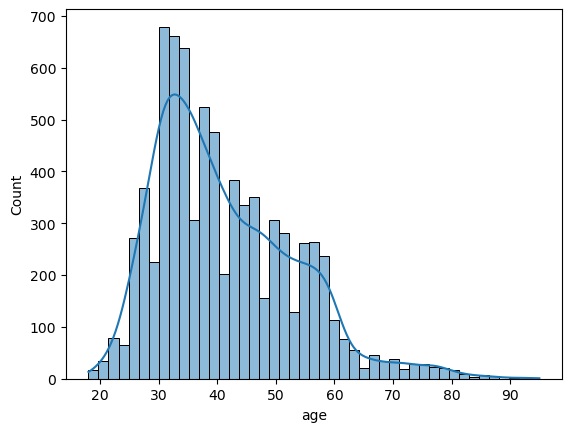



balance


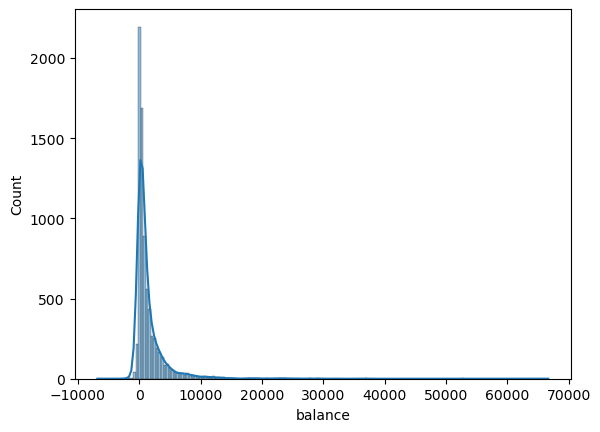



campaign


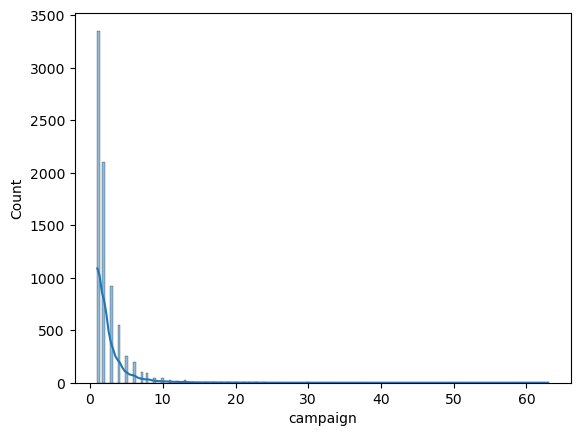



pdays


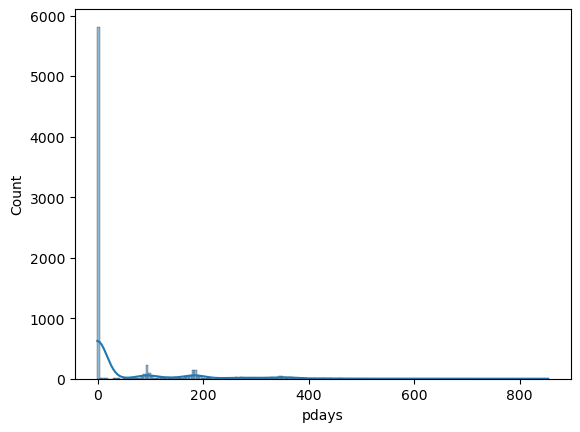

In [194]:
for i in df.select_dtypes('number').columns:
      print(i)
      sns.histplot(data=df, x=i, kde=True)
      plt.show()
      print('\n')


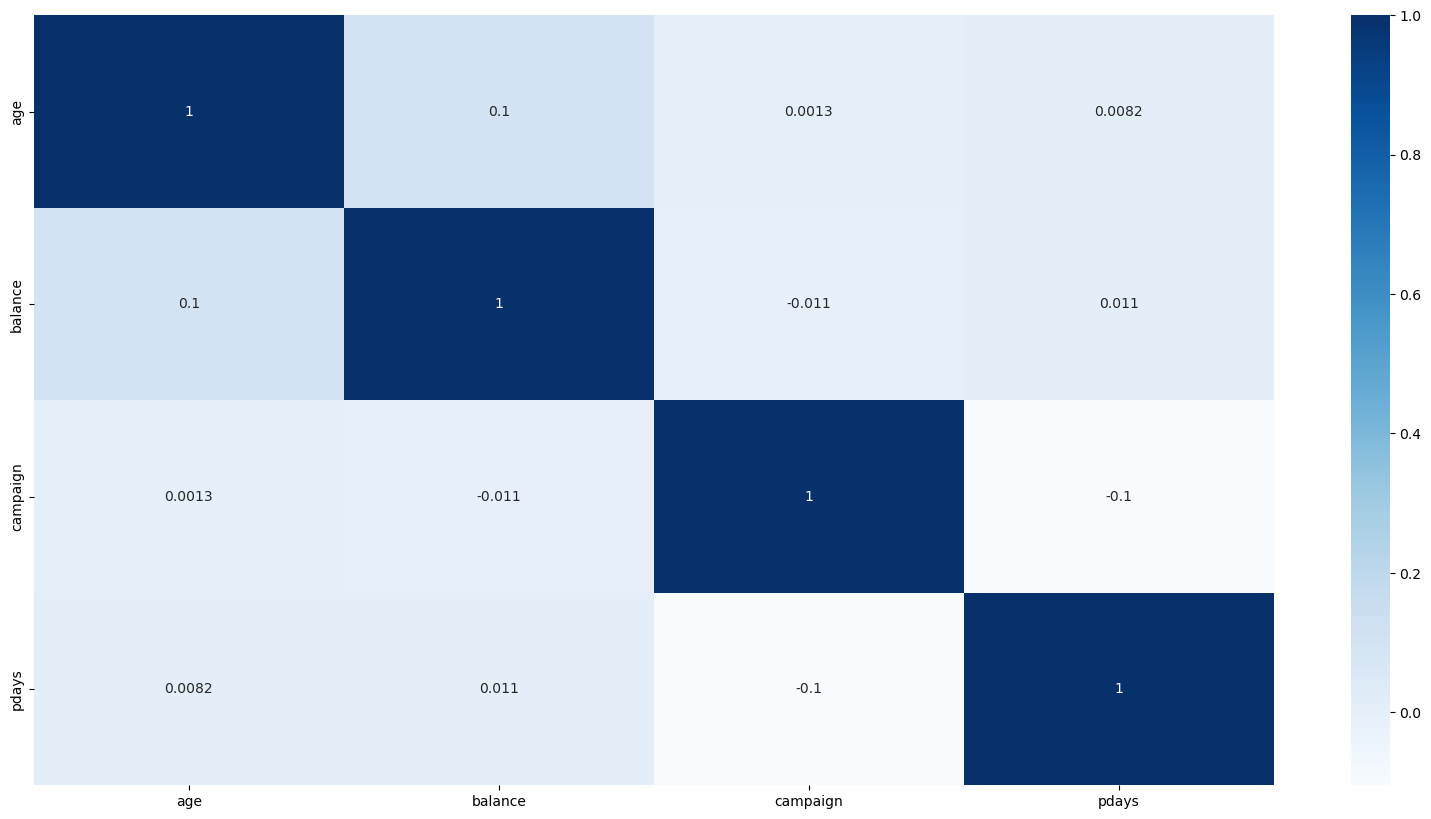

In [195]:
#cek multicolinearity kolom numerik
plt.figure(figsize=(20,10))
sns.heatmap(df.drop('deposit',axis=1).select_dtypes('number').corr(),annot=True,cmap='Blues')
plt.show()

## Define Features & Target

In [196]:
df.columns

Index(['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month',
       'campaign', 'pdays', 'poutcome', 'deposit'],
      dtype='object')

In [197]:
#Feature
X = df[[
    'age', 'job', 'balance', 'housing', 'loan',
    'contact', 'month', 'campaign', 'pdays', 'poutcome'
]]
X.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown
2,51,admin.,3025,no,no,cellular,may,1,352,unknown
3,38,services,-87,yes,no,cellular,may,1,-1,unknown
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown


In [198]:
#Target
y=df['deposit']
y.head()

0     True
1     True
2     True
3    False
4    False
Name: deposit, dtype: bool

## Split Data
`Train` : digunakan untuk melatih model

`Test` : digunakan untuk mengevaluasi model

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [200]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6244, 10)
(1561, 10)
(6244,)
(1561,)


## Feature Engineering

Preprocessing

**Numerical**
1. Age -> simple imputer median, standard scaler
1. Balance, Campaign, Pdays -> imputer median, robust scaler

**Categorical**
1. Job -> simple imputer constant "other", OneHotEncoder
1. Housing, Loan  -> simple imputer modus, one hot encoder
1. Contact, Poutcome -> OneHotEncoder
1. Month -> ordinal


In [201]:
preprocessor = ColumnTransformer(
    transformers=[
        ('Numerical 1',
         Pipeline(steps=[
             ('Imputer 1', SimpleImputer(strategy='median')),
             ('Scaler 1', StandardScaler())
         ]),
         ['age']),

        ('Numerical 2',
         Pipeline(steps=[
             ('Imputer 2', SimpleImputer(strategy='median')),
             ('Scaler 2', RobustScaler())
         ]),
        #  ['campaign', 'pdays']),
         ['balance', 'campaign', 'pdays']),


        ('Categorical 1',
         Pipeline(steps=[
             ('Imputer 3', SimpleImputer(
                 strategy='constant',
                 fill_value='other'
             )),
             ('Encoder 1', OneHotEncoder(
                 handle_unknown='ignore'
             ))
         ]),
         ['job']),

        ('Categorical 2',
         Pipeline(steps=[
             ('Imputer 4', SimpleImputer(
                 strategy='most_frequent'
             )),
             ('Encoder 2', OneHotEncoder(
                 handle_unknown='ignore'
             ))
         ]),
         ['housing', 'loan']),

        ('Categorical 3',
         Pipeline(steps=[
             ('Encoder 3', OneHotEncoder(
                 handle_unknown='ignore'
             ))
         ]),
         ['contact', 'poutcome']),

        ('Categorical 4',
        Pipeline([
            ('Encoder 4', OrdinalEncoder(
                categories=[[
                    'jan', 'feb', 'mar', 'apr',
                    'may', 'jun', 'jul', 'aug',
                    'sep', 'oct', 'nov', 'dec'
                ]]
            ))
        ]),
        ['month'])
   ],
    remainder='drop'
)

## Modeling + Cross Validation

### Initial Model Benchmarking

In [202]:
# Strategi cross-validation yang konsisten untuk seluruh model
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


### KNN

In [203]:
# Pipeline KNN: preprocessing dilakukan di setiap fold CV
knn_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

scores_knn_cv = cross_val_score(
    estimator=knn_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

scores_knn_cv


array([0.6281407 , 0.59128978, 0.57621441, 0.61976549, 0.63255034])

In [204]:
print(f'Mean Recall: {scores_knn_cv.mean()}')
print(f'Standard Deviation: {scores_knn_cv.std()}')

Mean Recall: 0.6095921441660203
Standard Deviation: 0.022016696191388123


### Logistic Regression

In [205]:
# Pipeline Logistic Regression:
# preprocessing dilakukan secara terpisah pada setiap fold CV
logreg_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

scores_logreg_cv = cross_val_score(
    estimator=logreg_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

scores_logreg_cv


array([0.62479062, 0.59296482, 0.57118928, 0.63149079, 0.6090604 ])

In [206]:
print(f'Mean Recall: {scores_logreg_cv.mean()}')
print(f'Standard Deviation: {scores_logreg_cv.std()}')

Mean Recall: 0.6058991827144673
Standard Deviation: 0.021880973134438732


### Decision Tree

In [207]:
# Pipeline Decision Tree:
# preprocessing dilakukan secara terpisah pada setiap fold CV
tree_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

scores_tree_cv = cross_val_score(
    estimator=tree_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

scores_tree_cv


array([0.60469012, 0.63316583, 0.60469012, 0.61809045, 0.6090604 ])

In [208]:
print(f'Mean Recall: {scores_tree_cv.mean()}')
print(f'Standard Deviation: {scores_tree_cv.std()}')

Mean Recall: 0.6139393837194923
Standard Deviation: 0.010786935524466386


### BoostIng Classifier : XGBoost

In [209]:
# Pipeline XGBoost:
# preprocessing dilakukan secara terpisah pada setiap fold CV
xgb_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

scores_xgb_cv = cross_val_score(
    estimator=xgb_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

scores_xgb_cv


array([0.66499162, 0.64656616, 0.58626466, 0.66499162, 0.6090604 ])

In [210]:
print(f'Mean Recall: {scores_xgb_cv.mean()}')
print(f'Standard Deviation: {scores_xgb_cv.std()}')

Mean Recall: 0.6343748946072645
Standard Deviation: 0.03155570911339207


### BoostIng Classifier : Ada Boost

In [211]:
# Pipeline AdaBoost:
# preprocessing dilakukan secara terpisah pada setiap fold CV
adaboost_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# Evaluasi recall dengan 5-fold cross-validation
scores_adaboost_cv = cross_val_score(
    estimator=adaboost_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

scores_adaboost_cv


array([0.25460637, 0.24120603, 0.2361809 , 0.24958124, 0.26510067])

In [212]:
print(f'Mean Recall: {scores_adaboost_cv.mean()}')
print(f'Standard Deviation: {scores_adaboost_cv.std()}')

Mean Recall: 0.24933504210088472
Standard Deviation: 0.010153961686958049


### BoostIng Classifier : Cat Boost

In [213]:
# Pipeline CatBoost:
# preprocessing dilakukan secara terpisah pada setiap fold CV
catboost_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(
        iterations=200,
        depth=5,
        learning_rate=0.05,
        loss_function='Logloss',
        random_seed=42,
        verbose=0,
        thread_count=-1
    ))
])

# Evaluasi recall dengan 5-fold cross-validation
scores_catboost_cv = cross_val_score(
    estimator=catboost_cv,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=1
)

scores_catboost_cv


array([0.66164154, 0.60469012, 0.57788945, 0.62981575, 0.60067114])

In [214]:
print(f'Mean Recall: {scores_catboost_cv.mean()}')
print(f'Standard Deviation: {scores_catboost_cv.std()}')

Mean Recall: 0.614941598372174
Standard Deviation: 0.02857875301315384


In [215]:
# Model benchmarking
df_final = pd.DataFrame({
    'Model': [
        'KNN',
        'Decision Tree',
        'Logistic Regression',
        'XGBoost',
        'AdaBoost',
        'CatBoost'
    ],
    'avg_recall_cv': [
        scores_knn_cv.mean(),
        scores_tree_cv.mean(),
        scores_logreg_cv.mean(),
        scores_xgb_cv.mean(),
        scores_adaboost_cv.mean(),
        scores_catboost_cv.mean()
    ],
    'std_recall_cv': [
        scores_knn_cv.std(),
        scores_tree_cv.std(),
        scores_logreg_cv.std(),
        scores_xgb_cv.std(),
        scores_adaboost_cv.std(),
        scores_catboost_cv.std()
    ]
})

df_final = (
    df_final
    .sort_values(
        by=['avg_recall_cv', 'std_recall_cv'],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

df_final

,Model,avg_recall_cv,std_recall_cv
0,XGBoost,0.634375,0.031556
1,CatBoost,0.614942,0.028579
2,Decision Tree,0.613939,0.010787
3,KNN,0.609592,0.022017
4,Logistic Regression,0.605899,0.021881
5,AdaBoost,0.249335,0.010154


## Hyperparameter Tuning

### GridSearch CV

In [216]:
XGBClassifier().get_params()


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [217]:
gscv = GridSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        ))
    ]),

    param_grid={
        'model__n_estimators': [
            100, 200, 300
        ],
        'model__max_depth': [
            2, 3, 5
        ],
        'model__learning_rate': [
            0.01, 0.05, 0.1
        ],
        'model__scale_pos_weight': [
            1, 1.25, 1.5
        ]
    },

    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True
)

# Fit menggunakan data mentah
gscv.fit(X_train, y_train)

# Ambil pipeline terbaik
best_model = gscv.best_estimator_

print('Parameter terbaik:', gscv.best_params_)
print('Recall CV terbaik:', gscv.best_score_)


Parameter terbaik: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1.5}
Recall CV terbaik: 0.9108579811810731


In [218]:
pd.DataFrame(gscv.cv_results_).sort_values(by=['mean_test_score'], ascending=False).reset_index(drop=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__scale_pos_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.266382,0.013785,0.057122,0.007515,0.01,3,100,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.896147,0.924623,0.916248,0.906198,0.911074,0.910858,0.009557,1,0.914956,0.906577,0.910348,0.911605,0.911642,0.911025,0.002699
1,0.217683,0.013740,0.052073,0.005627,0.01,2,100,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.891122,0.917923,0.914573,0.907873,0.906040,0.907506,0.009265,2,0.913280,0.900712,0.909929,0.912442,0.909129,0.909099,0.004465
2,0.206732,0.007820,0.045330,0.003010,0.01,2,100,1.25,"{'model__learning_rate': 0.01, 'model__max_dep...",0.889447,0.917923,0.909548,0.901173,0.904362,0.904491,0.009416,3,0.907834,0.900712,0.902807,0.908672,0.904104,0.904826,0.003012
3,0.362503,0.012368,0.059438,0.007631,0.01,2,200,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.887772,0.897822,0.902848,0.889447,0.890940,0.893766,0.005683,4,0.907834,0.882279,0.904064,0.891496,0.896147,0.896364,0.009088
4,0.344940,0.022529,0.055187,0.009349,0.01,5,100,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.872697,0.911223,0.872697,0.862647,0.894295,0.882712,0.017608,5,0.894009,0.899874,0.891915,0.886049,0.909129,0.896195,0.007834
5,0.417568,0.005531,0.055869,0.002837,0.01,3,200,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.872697,0.884422,0.844221,0.869347,0.880872,0.870312,0.014128,6,0.883117,0.868035,0.863427,0.880603,0.881910,0.875418,0.008082
6,0.475843,0.026196,0.058403,0.005238,0.01,2,300,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.872697,0.881072,0.839196,0.867672,0.872483,0.866624,0.014376,7,0.878928,0.868454,0.863008,0.876414,0.876884,0.872738,0.006034
7,0.540541,0.017819,0.056266,0.002884,0.01,3,300,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.837521,0.844221,0.793970,0.827471,0.818792,0.824395,0.017504,8,0.844156,0.830750,0.824047,0.835358,0.829564,0.832775,0.006735
8,0.256044,0.015359,0.055440,0.003422,0.05,2,100,1.50,"{'model__learning_rate': 0.05, 'model__max_dep...",0.829146,0.839196,0.787270,0.815745,0.817114,0.817694,0.017454,9,0.842899,0.821114,0.821952,0.825723,0.831658,0.828669,0.008029
9,0.612208,0.017851,0.061015,0.007060,0.01,5,200,1.50,"{'model__learning_rate': 0.01, 'model__max_dep...",0.820771,0.845896,0.777219,0.825796,0.803691,0.814675,0.023061,10,0.844156,0.827817,0.819858,0.851278,0.833752,0.835372,0.011230


In [219]:
gscv.best_params_

{'model__learning_rate': 0.01,
 'model__max_depth': 3,
 'model__n_estimators': 100,
 'model__scale_pos_weight': 1.5}

### Best Model

In [220]:
best_model=gscv.best_estimator_
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical 1', ...), ('Numerical 2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [221]:
# Evaluasi kestabilan parameter terbaik berdasarkan cross-validation
best_index_gscv = gscv.best_index_

recall_train_cv = gscv.cv_results_['mean_train_score'][best_index_gscv]
recall_validation_cv = gscv.cv_results_['mean_test_score'][best_index_gscv]
gap_cv = recall_train_cv - recall_validation_cv

df_tuning_evaluation = pd.DataFrame({
    'Model': ['XGBoost GridSearchCV'],
    'Recall_Train_CV': [recall_train_cv],
    'Recall_Validation_CV': [recall_validation_cv],
    'Gap_CV': [gap_cv],
    'Absolute_Gap_CV': [abs(gap_cv)]
})

display(
    df_tuning_evaluation.style.format({
        'Recall_Train_CV': '{:.2%}',
        'Recall_Validation_CV': '{:.2%}',
        'Gap_CV': '{:+.2%}',
        'Absolute_Gap_CV': '{:.2%}'
    })
)


,Model,Recall_Train_CV,Recall_Validation_CV,Gap_CV,Absolute_Gap_CV
0,XGBoost GridSearchCV,91.10%,91.09%,+0.02%,0.02%


### Final Model Benchmarking


In [222]:
# ============================================================
# BENCHMARKING MODEL – RECALL CROSS-VALIDATION
# ============================================================

# Index parameter terbaik GridSearchCV
best_index_gscv = gscv.best_index_

# Simpan hasil benchmarking
benchmark_results = [
    {
        'Model': 'XGBoost Default',
        'Avg_Recall_CV': (
            scores_xgb_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_xgb_cv.std()
        )
    },
    {
        'Model': 'XGBoost GridSearchCV',
        'Avg_Recall_CV': (
            gscv.best_score_
        ),
        'Std_Recall_CV': (
            gscv.cv_results_[
                'std_test_score'
            ][best_index_gscv]
        )
    },
    {
        'Model': 'CatBoost',
        'Avg_Recall_CV': (
            scores_catboost_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_catboost_cv.std()
        )
    },
    {
        'Model': 'AdaBoost',
        'Avg_Recall_CV': (
            scores_adaboost_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_adaboost_cv.std()
        )
    },
    {
        'Model': 'KNN',
        'Avg_Recall_CV': (
            scores_knn_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_knn_cv.std()
        )
    },
    {
        'Model': 'Logistic Regression',
        'Avg_Recall_CV': (
            scores_logreg_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_logreg_cv.std()
        )
    },
    {
        'Model': 'Decision Tree',
        'Avg_Recall_CV': (
            scores_tree_cv.mean()
        ),
        'Std_Recall_CV': (
            scores_tree_cv.std()
        )
    }
]

# Buat DataFrame
df_final = pd.DataFrame(
    benchmark_results
)

# Urutkan berdasarkan:
# 1. Rata-rata recall CV tertinggi
# 2. Standar deviasi terkecil
df_final = (
    df_final
    .sort_values(
        by=[
            'Avg_Recall_CV',
            'Std_Recall_CV'
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

# Tambahkan ranking
df_final.insert(
    0,
    'Rank',
    range(1, len(df_final) + 1)
)

# Tampilkan sebagai persentase
display(
    df_final.style.format({
        'Avg_Recall_CV': '{:.2%}',
        'Std_Recall_CV': '{:.2%}'
    })
)

,Rank,Model,Avg_Recall_CV,Std_Recall_CV
0,1,XGBoost GridSearchCV,91.09%,0.96%
1,2,XGBoost Default,63.44%,3.16%
2,3,CatBoost,61.49%,2.86%
3,4,Decision Tree,61.39%,1.08%
4,5,KNN,60.96%,2.20%
5,6,Logistic Regression,60.59%,2.19%
6,7,AdaBoost,24.93%,1.02%


### FEATURE IMPORTANCE

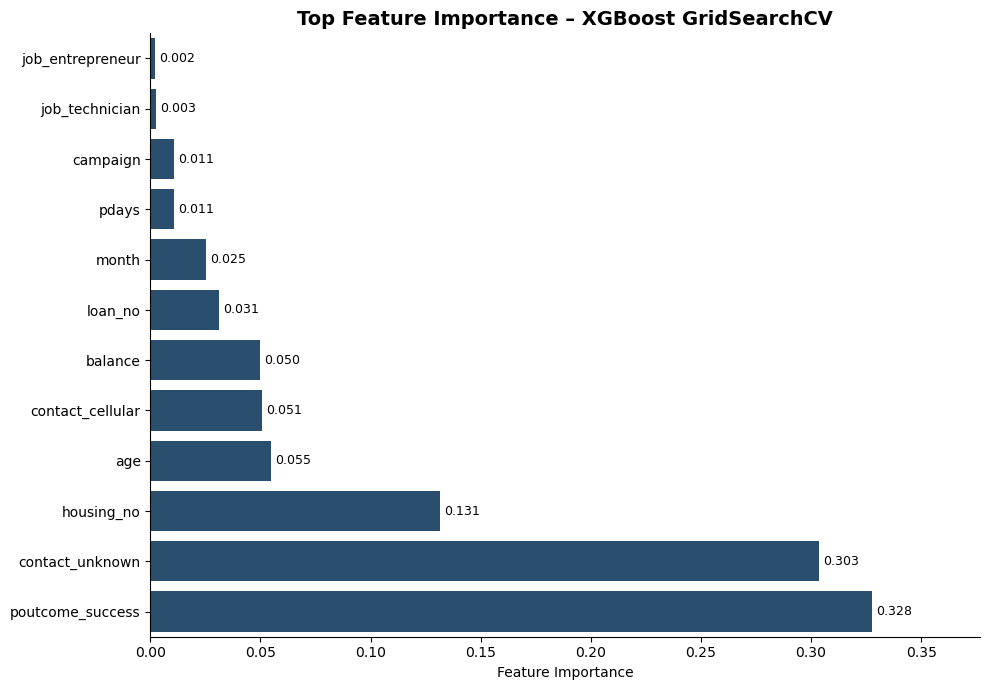

In [223]:
# ============================================================
# FEATURE IMPORTANCE – XGBOOST GRIDSEARCHCV
# ============================================================

# Ambil komponen pipeline terbaik
best_preprocessor = best_model.named_steps['preprocessor']
best_xgb_model = best_model.named_steps['model']

# Ambil nama fitur hasil preprocessing dari pipeline fitted
feature_names = (
    best_preprocessor
    .get_feature_names_out()
)

# Ambil feature importance XGBoost
feature_importance = (
    best_xgb_model
    .feature_importances_
)

# Validasi jumlah fitur
if len(feature_names) != len(feature_importance):
    raise ValueError(
        f'Jumlah nama fitur ({len(feature_names)}) '
        f'tidak sama dengan jumlah feature importance '
        f'({len(feature_importance)}).'
    )

# Buat DataFrame
df_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Bersihkan prefix dari ColumnTransformer
df_importance_xgb['Feature'] = (
    df_importance_xgb['Feature']
    .str.replace(
        r'^[^_]+__',
        '',
        regex=True
    )
)

# Hilangkan fitur dengan importance nol,
# ambil maksimal 20 fitur terpenting
df_plot_xgb = (
    df_importance_xgb
    .query('Importance > 0')
    .sort_values(
        by='Importance',
        ascending=False
    )
    .head(20)
    .sort_values(
        by='Importance',
        ascending=True
    )
)

# ============================================================
# VISUALISASI
# ============================================================

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=df_plot_xgb,
    x='Importance',
    y='Feature',
    color='#1F4E79'
)

# Tampilkan nilai pada bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )

plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title(
    'Top Feature Importance – XGBoost GridSearchCV',
    fontsize=14,
    fontweight='bold'
)

# Beri ruang untuk label nilai
plt.xlim(
    0,
    df_plot_xgb['Importance'].max() * 1.15
)

sns.despine()
plt.tight_layout()
plt.show()

## Model Evaluation

### Objective Machine Learning

1. **False Positive (FP):** Model memprediksi nasabah akan membuka deposito, tetapi pada kenyataannya tidak. Dampaknya adalah biaya dan sumber daya campaign digunakan untuk nasabah yang tidak melakukan konversi.

2. **False Negative (FN):** Model memprediksi nasabah tidak akan membuka deposito, tetapi pada kenyataannya nasabah tersebut membuka deposito. Dampaknya adalah nasabah potensial tidak menjadi target campaign sehingga peluang bisnis dapat terlewat.

**Recall** dipilih sebagai evaluation metric utama karena tujuan model adalah mengidentifikasi sebanyak mungkin nasabah yang berpotensi membuka deposito dan meminimalkan jumlah **False Negative**.

Dengan recall yang tinggi, semakin sedikit nasabah potensial yang terlewat oleh model. Hal ini dapat memperluas cakupan target campaign dan mendukung peningkatan jumlah konversi, meskipun tidak secara langsung menjamin peningkatan *conversion rate*.


### Business Loss Analysis

Asumsi sensitivity analysis:

- `$10` adalah potential profit yang hilang untuk setiap False Negative.
- `$5` adalah biaya campaign tidak efektif untuk setiap False Positive, bukan biaya seluruh panggilan.

Rumus yang digunakan:

$$Business\ Loss=(FN\times C_{FN})+(FP\times C_{FP})$$


In [224]:
# Asumsi biaya untuk sensitivity analysis
potential_profit = 10
campaign_budget = 5


#### Scenario I (Without Model) : Tidak Ada Customer Ditelpon

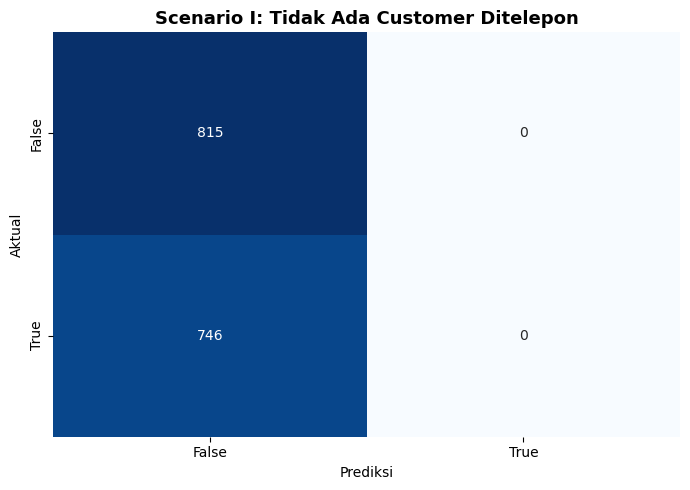

True Negative  (TN): 815
False Positive (FP): 0
False Negative (FN): 746
True Positive  (TP): 0


In [225]:
# ============================================================
# SCENARIO I – TIDAK ADA CUSTOMER DITELEPON
# ============================================================

# Semua customer diprediksi False
y_pred_none = np.full(
    shape=len(y_test),
    fill_value=False,
    dtype=bool
)

# Confusion matrix
cm_none = confusion_matrix(
    y_test,
    y_pred_none,
    labels=[False, True]
)

# Ambil komponennya
tn_none, fp_none, fn_none, tp_none = (
    cm_none.ravel()
)

# Visualisasi
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_none,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=[False, True],
    yticklabels=[False, True]
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(
    'Scenario I: Tidak Ada Customer Ditelepon',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Ringkasan confusion matrix
print(f'True Negative  (TN): {tn_none}')
print(f'False Positive (FP): {fp_none}')
print(f'False Negative (FN): {fn_none}')
print(f'True Positive  (TP): {tp_none}')

In [226]:
business_loss_no_campaign = (
    fn_none * potential_profit +
    fp_none * campaign_budget
)

print(
    'Business Loss Scenario I: '
    f'({fn_none} × ${potential_profit}) + '
    f'({fp_none} × ${campaign_budget}) '
    f'= ${business_loss_no_campaign:,.0f}'
)


Business Loss Scenario I: (746 × $10) + (0 × $5) = $7,460


#### Scenario II ( Without Model) : Semua Customer Ditelpon

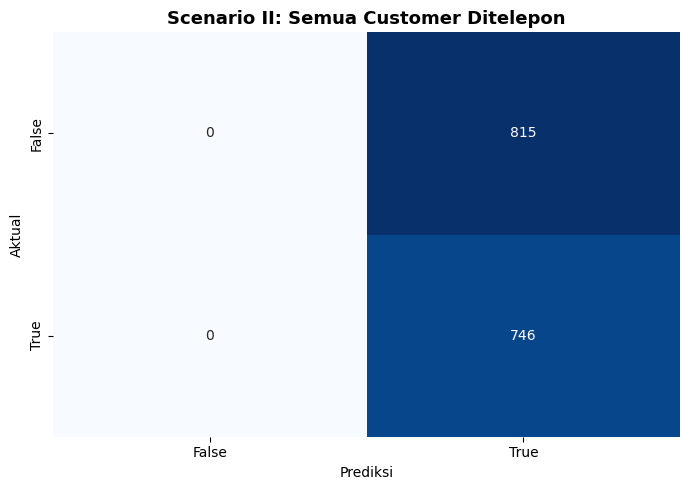

True Negative  (TN): 0
False Positive (FP): 815
False Negative (FN): 0
True Positive  (TP): 746


In [227]:
# ============================================================
# SCENARIO II – SEMUA CUSTOMER DITELEPON
# ============================================================

# Semua customer diprediksi True
y_pred_all = np.full(
    shape=len(y_test),
    fill_value=True,
    dtype=bool
)

# Confusion matrix
cm_all = confusion_matrix(
    y_test,
    y_pred_all,
    labels=[False, True]
)

# Ambil komponen confusion matrix
tn_all, fp_all, fn_all, tp_all = (
    cm_all.ravel()
)

# Visualisasi
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_all,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=[False, True],
    yticklabels=[False, True]
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(
    'Scenario II: Semua Customer Ditelepon',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Ringkasan confusion matrix
print(f'True Negative  (TN): {tn_all}')
print(f'False Positive (FP): {fp_all}')
print(f'False Negative (FN): {fn_all}')
print(f'True Positive  (TP): {tp_all}')

In [228]:
business_loss_all_customer = (
    fn_all * potential_profit +
    fp_all * campaign_budget
)

print(
    'Business Loss Scenario II: '
    f'({fn_all} × ${potential_profit}) + '
    f'({fp_all} × ${campaign_budget}) '
    f'= ${business_loss_all_customer:,.0f}'
)


Business Loss Scenario II: (0 × $10) + (815 × $5) = $4,075


#### Scenario III (With Model)

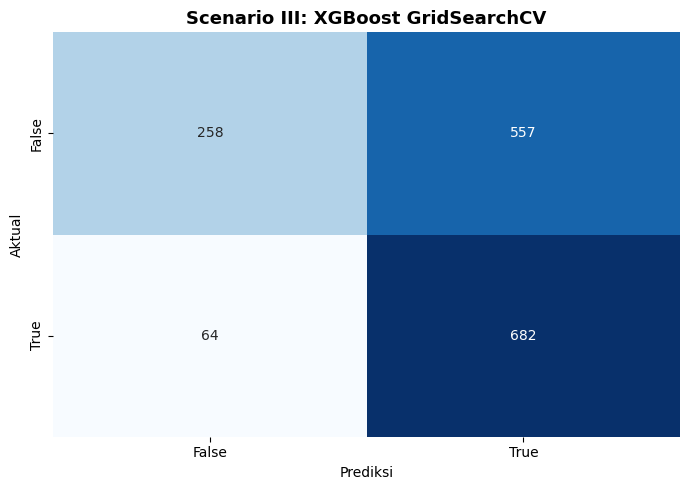

True Negative  (TN): 258
False Positive (FP): 557
False Negative (FN): 64
True Positive  (TP): 682


In [229]:
# ============================================================
# SCENARIO III – MENGGUNAKAN MODEL FINAL
# ============================================================

# Pipeline terbaik hasil GridSearchCV
best_model = gscv.best_estimator_

# Prediksi data test
y_pred_final = best_model.predict(X_test)

# Confusion matrix
cm_model = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[False, True]
)

# Ambil komponen confusion matrix
tn_model, fp_model, fn_model, tp_model = (
    cm_model.ravel()
)

# Visualisasi
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_model,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=[False, True],
    yticklabels=[False, True]
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(
    'Scenario III: XGBoost GridSearchCV',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Ringkasan confusion matrix
print(f'True Negative  (TN): {tn_model}')
print(f'False Positive (FP): {fp_model}')
print(f'False Negative (FN): {fn_model}')
print(f'True Positive  (TP): {tp_model}')

In [230]:
business_loss_model = (
    fn_model * potential_profit +
    fp_model * campaign_budget
)

print(
    'Business Loss Scenario III: '
    f'({fn_model} × ${potential_profit}) + '
    f'({fp_model} × ${campaign_budget}) '
    f'= ${business_loss_model:,.0f}'
)


Business Loss Scenario III: (64 × $10) + (557 × $5) = $3,425


## Model Benchmarking

ROC AUC Test: 0.7505


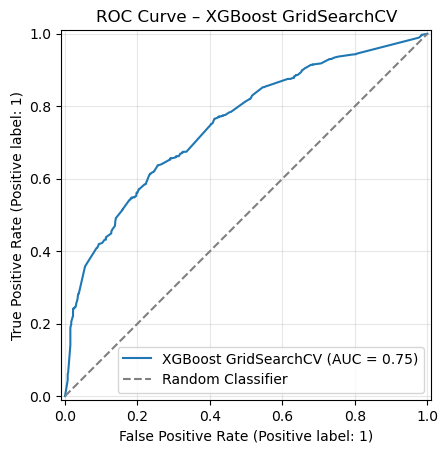

In [231]:
# Probabilitas kelas positif
y_proba_gscv_test = best_model.predict_proba(
    X_test
)[:, 1]

# Hitung ROC AUC
roc_auc_test = roc_auc_score(
    y_test,
    y_proba_gscv_test
)

print(
    f'ROC AUC Test: {roc_auc_test:.4f}'
)

# Visualisasi ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_gscv_test,
    name='XGBoost GridSearchCV'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Random Classifier'
)

plt.title(
    'ROC Curve – XGBoost GridSearchCV'
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [232]:
# ============================================================
# FINAL MODEL EVALUATION – XGBOOST GRIDSEARCHCV
# ============================================================

# ------------------------------------------------------------
# 1. Model dan prediksi
# ------------------------------------------------------------

best_model = gscv.best_estimator_

# Prediksi kelas
y_pred_final = best_model.predict(X_test)

# Probabilitas kelas positif
y_proba_final = best_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 2. Confusion matrix
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[False, True]
).ravel()


# ------------------------------------------------------------
# 3. Evaluation metrics
# ------------------------------------------------------------

recall_final = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)

roc_auc_final = roc_auc_score(
    y_test,
    y_proba_final
)


# ------------------------------------------------------------
# 4. Business loss
# ------------------------------------------------------------

# Asumsi biaya
potential_profit = 10
campaign_budget = 5

# Skenario menggunakan model
business_loss_model = (
    fn * potential_profit +
    fp * campaign_budget
)

# Jumlah kelas aktual
actual_positive = tp + fn
actual_negative = tn + fp

# Skenario tidak menjalankan campaign
business_loss_no_campaign = (
    actual_positive * potential_profit
)

# Skenario menghubungi semua customer
business_loss_all_customer = (
    actual_negative * campaign_budget
)


# ------------------------------------------------------------
# 5. Tabel akhir evaluation metrics
# ------------------------------------------------------------

df_evaluation = pd.DataFrame({
    'Evaluation Metric': [
        'Recall',
        'Business Loss',
        'ROC AUC'
    ],
    'Nilai': [
        f'{recall_final:.2%}',
        f'${business_loss_model:,.0f}',
        f'{roc_auc_final:.2%}'
    ],
    'Kategori': [
        'Metrik utama',
        'Evaluasi bisnis utama',
        'Metrik pendukung'
    ]
})

display(df_evaluation)


# ------------------------------------------------------------
# 6. Perbandingan business loss
# ------------------------------------------------------------

df_business_loss = pd.DataFrame({
    'Skenario': [
        'Tidak Menjalankan Campaign',
        'Menghubungi Semua Customer',
        'Menggunakan Model'
    ],
    'Business Loss': [
        business_loss_no_campaign,
        business_loss_all_customer,
        business_loss_model
    ]
})

df_business_loss = (
    df_business_loss
    .sort_values(
        by='Business Loss',
        ascending=True
    )
    .reset_index(drop=True)
)

df_business_loss.insert(
    0,
    'Ranking',
    range(1, len(df_business_loss) + 1)
)

# Format mata uang hanya untuk tampilan
df_business_loss['Business Loss'] = (
    df_business_loss['Business Loss']
    .map('${:,.0f}'.format)
)

display(df_business_loss)


,Evaluation Metric,Nilai,Kategori
0,Recall,91.42%,Metrik utama
1,Business Loss,"$3,425",Evaluasi bisnis utama
2,ROC AUC,75.05%,Metrik pendukung


,Ranking,Skenario,Business Loss
0,1,Menggunakan Model,"$3,425"
1,2,Menghubungi Semua Customer,"$4,075"
2,3,Tidak Menjalankan Campaign,"$7,460"


In [233]:
# ============================================================
# EXPORT MODEL FINAL DAN METADATA
# ============================================================

import pickle

best_model = gscv.best_estimator_

with open('best_model.sav', 'wb') as file:
    pickle.dump(
        best_model,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print('Model berhasil disimpan sebagai best_model.sav')

Model berhasil disimpan sebagai best_model.sav
